In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load and inspect the data

Keep the CSV in the same folder as this notebook. `CustomerID` is an identifier, so it is not used for clustering. `Gender` is also excluded so a binary category does not receive the same distance weight as each continuous customer measure.


In [2]:
data_path = Path("Mall_Customers(1).csv")
if not data_path.exists():
    data_path = Path("Mall_Customers.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Place Mall_Customers(1).csv or Mall_Customers.csv in the same folder as this notebook."
    )

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum().to_string())
print("\nFirst five rows:")
print(df.head().to_string(index=False))


Dataset shape: (200, 5)

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0

First five rows:
 CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
          1   Male   19                  15                      39
          2   Male   21                  15                      81
          3 Female   20                  16                       6
          4 Female   23                  16                      77
          5 Female   31                  17                      40


## 2. Select and scale the clustering features


In [3]:
feature_cols = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
]

X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_check = pd.DataFrame({
    "Feature": feature_cols,
    "Scaled mean": X_scaled.mean(axis=0),
    "Scaled standard deviation": X_scaled.std(axis=0),
})

print(scaled_check.round(3).to_string(index=False))


               Feature  Scaled mean  Scaled standard deviation
                   Age         -0.0                        1.0
    Annual Income (k$)         -0.0                        1.0
Spending Score (1-100)         -0.0                        1.0


## 3. Elbow method for K-Means

The curve bends in the 4–5 cluster region. This notebook selects **k = 5**, which keeps the model simple while separating the important income-and-spending customer groups.


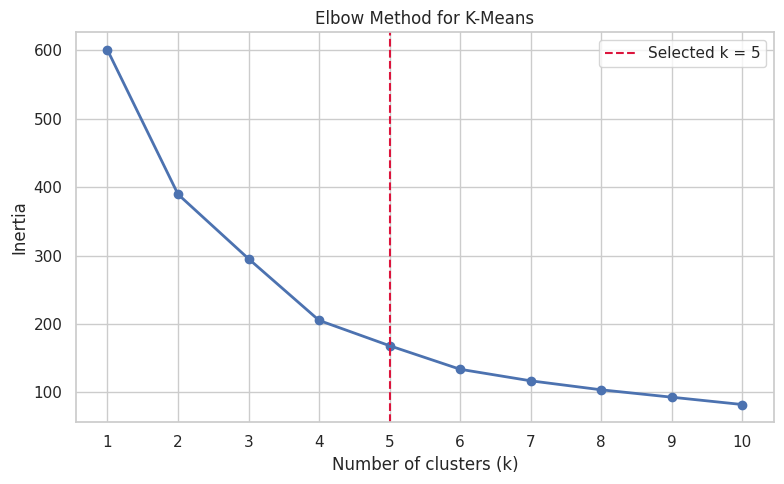

 k  Inertia
 1   600.00
 2   389.39
 3   295.21
 4   205.23
 5   168.25
 6   133.87
 7   117.01
 8   103.87
 9    93.09
10    82.39


In [4]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

selected_k = 5

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o", linewidth=2)
plt.axvline(selected_k, color="crimson", linestyle="--", label="Selected k = 5")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

elbow_table = pd.DataFrame({"k": list(k_values), "Inertia": inertias})
print(elbow_table.round(2).to_string(index=False))


## 4. Fit K-Means and summarize its clusters


In [5]:
kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

results = df.copy()
results["KMeans Cluster"] = kmeans_labels

kmeans_profile = (
    results.groupby("KMeans Cluster")[feature_cols]
    .mean()
    .round(1)
)
kmeans_profile.insert(0, "Customers", results["KMeans Cluster"].value_counts().sort_index())

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("K-Means cluster profiles:")
print(kmeans_profile.to_string())
print(f"\nK-Means silhouette score: {kmeans_silhouette:.3f}")


K-Means cluster profiles:
                Customers   Age  Annual Income (k$)  Spending Score (1-100)
KMeans Cluster                                                             
0                      20  46.2                26.8                    18.4
1                      54  25.2                41.1                    62.2
2                      40  32.9                86.1                    81.5
3                      39  39.9                86.1                    19.4
4                      47  55.6                54.4                    48.9

K-Means silhouette score: 0.417


### K-Means cluster descriptions

Cluster 0 contains 20 middle-aged customers with low income and low spending, so it represents cautious or infrequent shoppers. Cluster 1 contains 54 younger customers with lower-to-middle income and above-average spending, while Cluster 2 contains 40 high-income, high-spending customers who are the strongest premium segment. Cluster 3 contains 39 high-income but low-spending customers, making it the clearest group for targeted conversion campaigns. Cluster 4 contains 47 older customers with middle income and moderate spending, representing steady average-value shoppers.


## 5. Choose DBSCAN settings

The sorted distance to each customer's fifth-nearest neighbor helps choose `eps`. A value near **0.50** captures dense groups without merging nearly all customers into one cluster; `min_samples = 5` is used for the local density requirement.


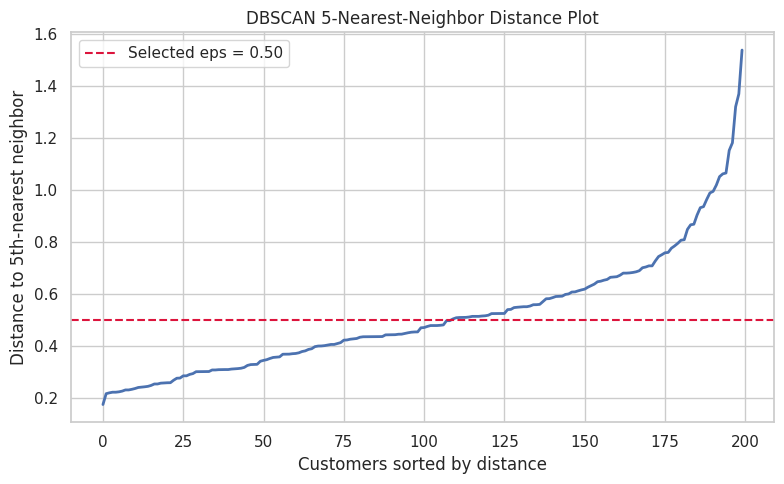

In [6]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, linewidth=2)
plt.axhline(0.50, color="crimson", linestyle="--", label="Selected eps = 0.50")
plt.title("DBSCAN 5-Nearest-Neighbor Distance Plot")
plt.xlabel("Customers sorted by distance")
plt.ylabel("Distance to 5th-nearest neighbor")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Fit DBSCAN and summarize its clusters


In [7]:
dbscan = DBSCAN(eps=0.50, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)
results["DBSCAN Cluster"] = dbscan_labels

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())

dbscan_profile = (
    results.groupby("DBSCAN Cluster")[feature_cols]
    .mean()
    .round(1)
)
dbscan_profile.insert(0, "Customers", results["DBSCAN Cluster"].value_counts().sort_index())

non_noise = dbscan_labels != -1
dbscan_silhouette = silhouette_score(
    X_scaled[non_noise], dbscan_labels[non_noise]
)

print(f"DBSCAN clusters: {n_dbscan_clusters}")
print(f"Noise points (-1): {n_noise}")
print("\nDBSCAN cluster profiles:")
print(dbscan_profile.to_string())
print(f"\nDBSCAN silhouette score on non-noise customers: {dbscan_silhouette:.3f}")


DBSCAN clusters: 6
Noise points (-1): 60

DBSCAN cluster profiles:
                Customers   Age  Annual Income (k$)  Spending Score (1-100)
DBSCAN Cluster                                                             
-1                     60  40.1                68.5                    31.5
 0                     17  23.8                25.8                    78.2
 1                      5  38.2                27.8                    31.8
 2                     51  53.7                54.2                    48.4
 3                     28  24.1                54.3                    50.5
 4                     32  32.8                80.9                    83.6
 5                      7  43.9                78.7                    14.6

DBSCAN silhouette score on non-noise customers: 0.482


### DBSCAN cluster descriptions

DBSCAN Cluster 0 represents young, low-income, high-spending customers, while the small Cluster 1 represents lower-income customers with lower spending. Clusters 2 and 3 are moderate-spending customers separated mainly by age: Cluster 2 is older and Cluster 3 is younger. Cluster 4 contains high-income, high-spending customers, while the small Cluster 5 contains high-income, low-spending customers. Label `-1` contains 60 sparse or borderline customers that DBSCAN treats as noise instead of forcing them into a group.


## 7. Reduce the scaled data to two PCA dimensions


In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["K-Means"] = kmeans_labels
pca_df["DBSCAN"] = dbscan_labels

explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explained variance: {explained[0]:.1f}%")
print(f"PC2 explained variance: {explained[1]:.1f}%")
print(f"Total explained variance: {explained.sum():.1f}%")


PC1 explained variance: 44.3%
PC2 explained variance: 33.3%
Total explained variance: 77.6%


## 8. PCA scatter plots for both algorithms


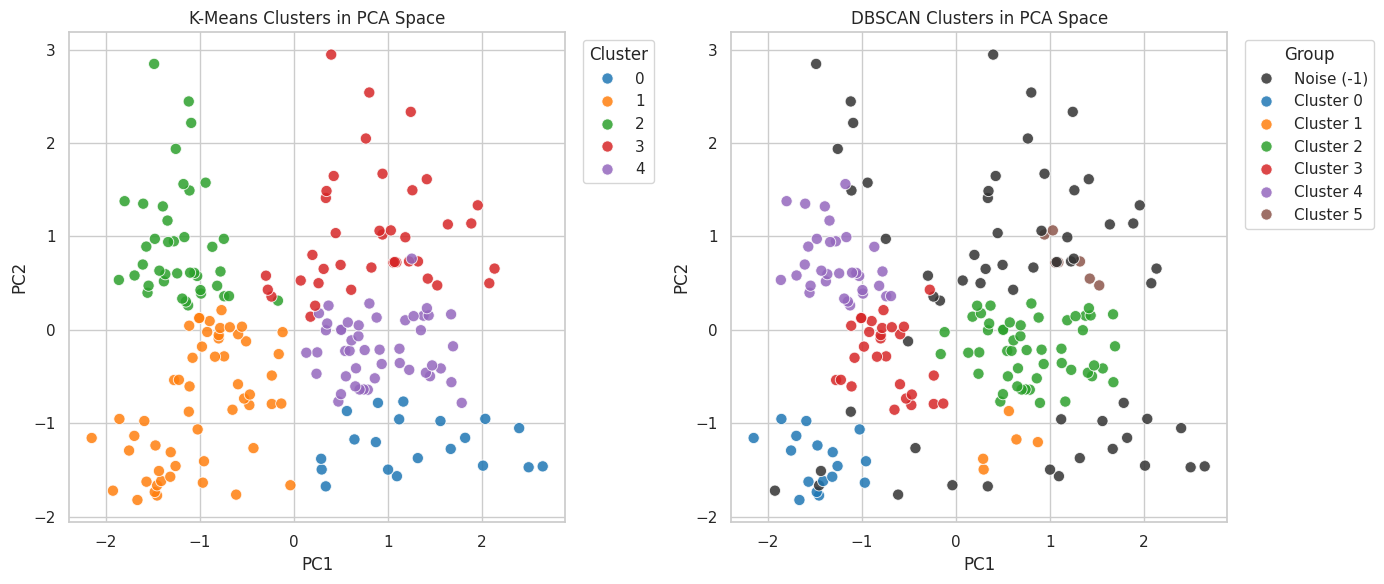

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="K-Means",
    palette="tab10",
    s=65,
    alpha=0.85,
    ax=axes[0],
)
axes[0].set_title("K-Means Clusters in PCA Space")
axes[0].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

dbscan_names = pca_df["DBSCAN"].map(
    lambda label: "Noise (-1)" if label == -1 else f"Cluster {label}"
)
dbscan_order = ["Noise (-1)"] + [
    f"Cluster {label}" for label in sorted(set(dbscan_labels)) if label != -1
]
colors = sns.color_palette("tab10", n_colors=n_dbscan_clusters)
dbscan_palette = {"Noise (-1)": "#333333"}
dbscan_palette.update({f"Cluster {i}": colors[i] for i in range(n_dbscan_clusters)})

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=dbscan_names,
    hue_order=dbscan_order,
    palette=dbscan_palette,
    s=65,
    alpha=0.85,
    ax=axes[1],
)
axes[1].set_title("DBSCAN Clusters in PCA Space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## 9. Compare K-Means and DBSCAN


In [10]:
ari_non_noise = adjusted_rand_score(
    kmeans_labels[non_noise], dbscan_labels[non_noise]
)

comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Clusters found": [selected_k, n_dbscan_clusters],
    "Noise points": [0, n_noise],
    "Silhouette score": [kmeans_silhouette, dbscan_silhouette],
    "Silhouette population": ["All customers", "Non-noise customers only"],
})

print(comparison.round({"Silhouette score": 3}).to_string(index=False))
print(f"\nAdjusted Rand Index on non-noise customers: {ari_non_noise:.3f}")


Algorithm  Clusters found  Noise points  Silhouette score    Silhouette population
  K-Means               5             0             0.417            All customers
   DBSCAN               6            60             0.482 Non-noise customers only

Adjusted Rand Index on non-noise customers: 0.758


### Comparison

K-Means places every customer into one of five broad segments, so it gives a complete and easy-to-use segmentation. DBSCAN finds six dense local groups and labels 60 customers as noise, showing that it is more conservative around sparse areas and cluster boundaries. The Adjusted Rand Index is about 0.758 for non-noise customers, so the methods broadly agree on the strongest dense patterns even though DBSCAN leaves many borderline customers unassigned. The DBSCAN silhouette value is calculated only on non-noise customers, so it should not be compared directly with the K-Means score without that limitation.
